In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


patients_path = '/media/Volume/data/MIMIC_IV/patients.csv.gz'
discharge_path = '/media/Volume/data/MIMIC_IV/discharge.csv.gz'
admissions_path = '/media/Volume/data/MIMIC_IV/admissions.csv.gz'
exams_path = '/media/Volume/data/MIMIC_IV/exams_filtered.csv'
out_path = '/media/Volume/data/MIMIC_IV/exams_cox_labels.csv'
icu_stays_path = '/media/Volume/data/MIMIC_IV/icustays.csv.gz'
dat_path = '/media/Volume/data/MIMIC_IV/record_list.csv'
machine_measurement_path = '/media/Volume/data/MIMIC_IV/machine_measurements.csv'
notes_path = '/media/Volume/data/MIMIC_IV/waveform_note_links.csv'

code_15_exams = '/media/Volume/data/CODE15/processed/exams_filtered.csv'

In [3]:
dat = pd.read_csv(dat_path)
dat

,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569
...,...,...,...,...,...
800030,19999840,48683947,48683947,2164-09-12 12:28:00,files/p1999/p19999840/s48683947/48683947
800031,19999840,41842293,41842293,2164-09-17 11:31:00,files/p1999/p19999840/s41842293/41842293
800032,19999987,41190887,41190887,2145-11-02 19:54:00,files/p1999/p19999987/s41190887/41190887
800033,19999987,45828463,45828463,2145-11-03 03:00:00,files/p1999/p19999987/s45828463/45828463


Nan detected:  3630


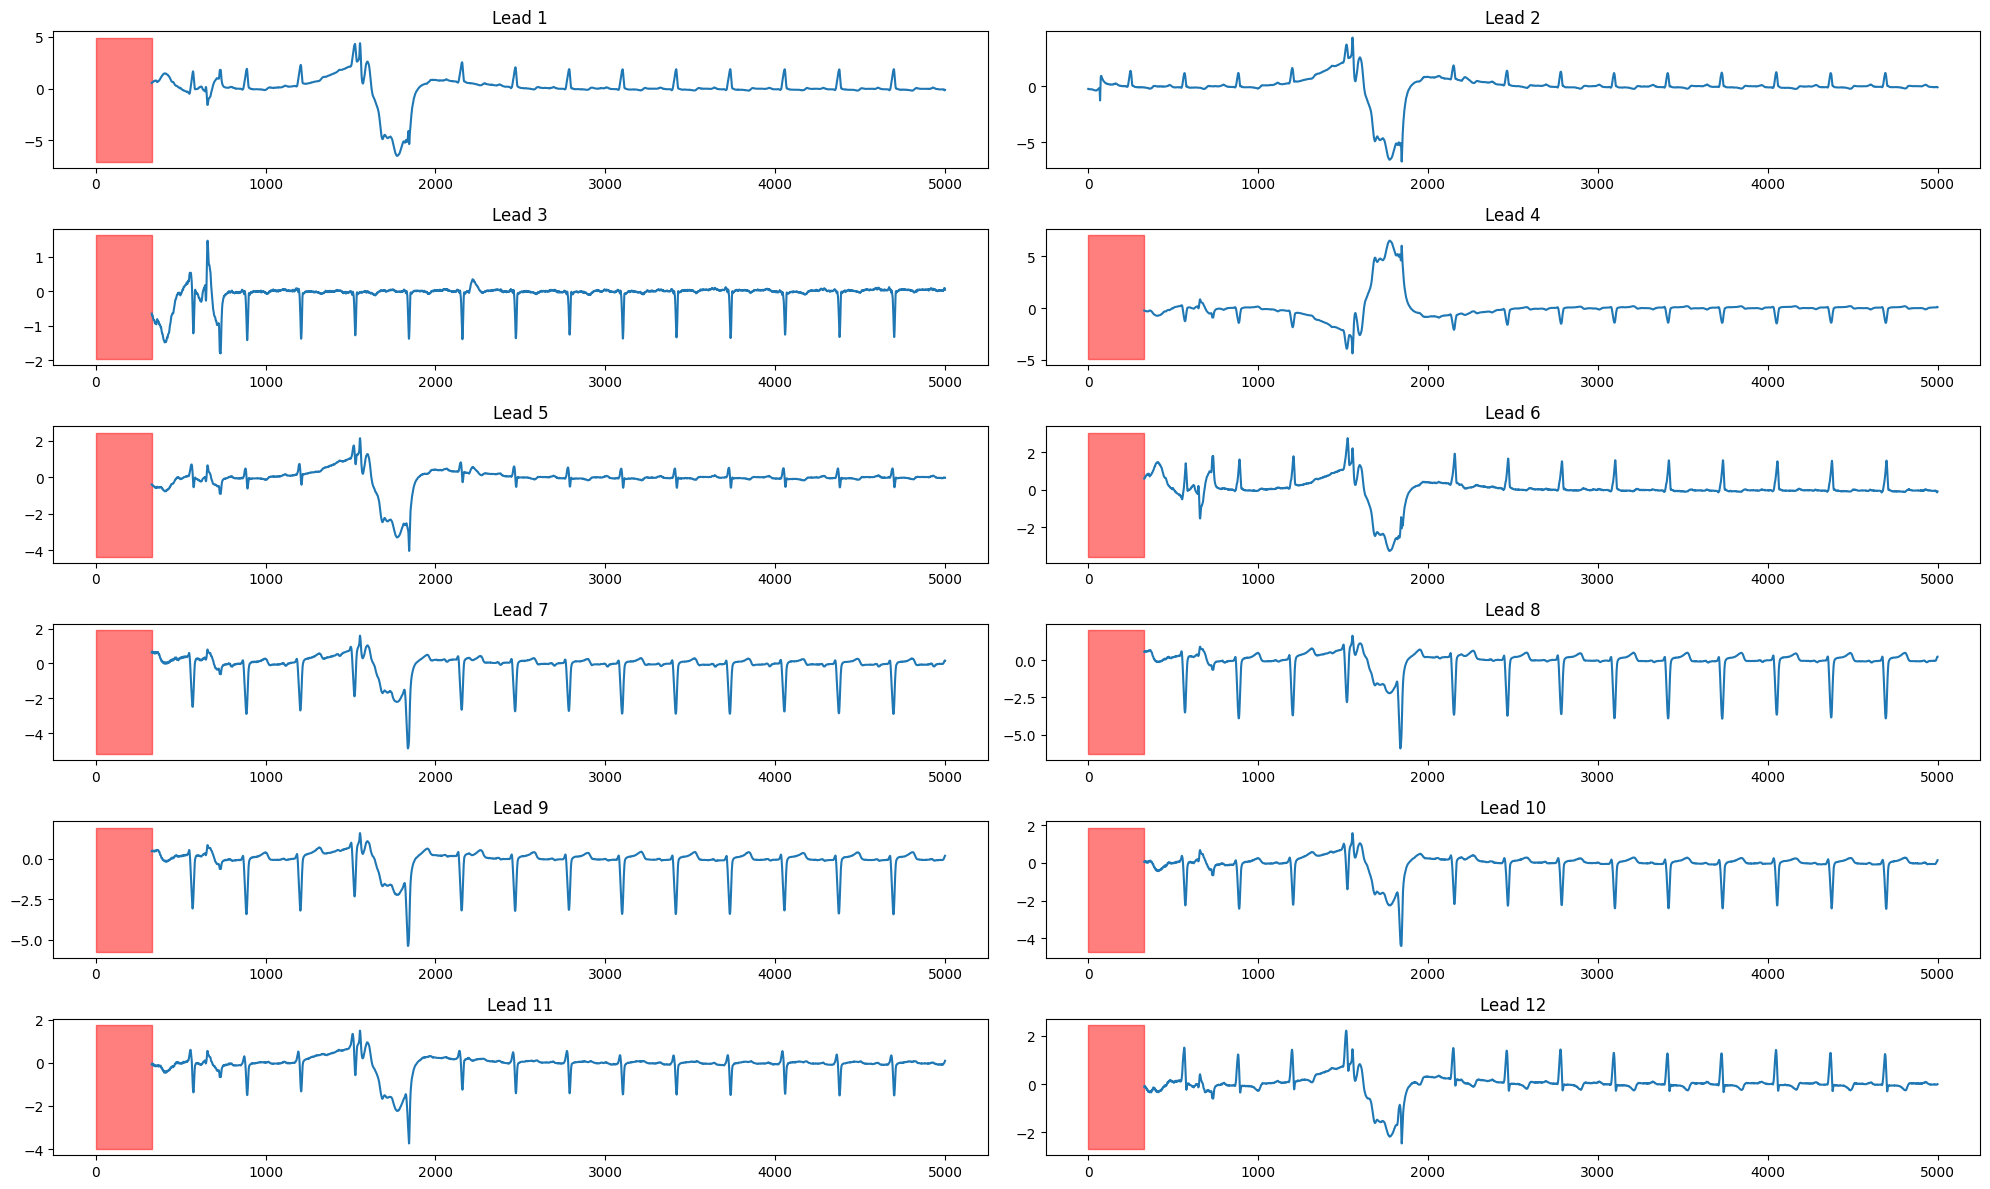

In [4]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

file_name = 'files/p1056/p10569454/s42081370/42081370'
signal, info = wfdb.rdsamp('/media/Volume/data/MIMIC_IV/' + file_name)
fig, axs = plt.subplots(6, 2, figsize=(20, 12))
leads = signal.shape[1]
print('Nan detected: ', np.sum(np.isnan(signal)))
# fillna
#signal = np.nan_to_num(signal)

for i in range(leads):
    ax = axs[i // 2, i % 2]
    sig = signal[:, i]

    ax.plot(sig)

    # Find NaNs and highlight them
    nan_mask = np.isnan(sig)
    ax.fill_between(np.arange(len(sig)), ax.get_ylim()[0], ax.get_ylim()[1], where=nan_mask, color="red", alpha=0.5)

    ax.set_title(f'Lead {i+1}')

plt.tight_layout()
plt.show()

In [5]:
code_15 = pd.read_csv(code_15_exams)
# drop unnamed 0 and unnamed 1
code_15 = code_15.loc[:, ~code_15.columns.str.contains('^Unnamed')]
# print columns
print(code_15.columns)
# remove null timey and death
code_15 = code_15[code_15['timey'].notna()]
code_15.head(n=10)

Index(['exam_id', 'age', 'is_male', 'nn_predicted_age', '1dAVb', 'RBBB',
       'LBBB', 'SB', 'ST', 'AF', 'patient_id', 'death', 'timey', 'normal_ecg',
       'trace_file', 'r_peaks', 'r_peak_interval_mean', 'r_peak_variance',
       'valid'],
      dtype='object')


,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file,r_peaks,r_peak_interval_mean,r_peak_variance,valid
0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5,[ 57 285 507 742 972 1196 1419 1630 1848 ...,0.625309,0.020557,True
1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5,[ 219 460 702 944 1176 1404 1631 1859 2080],0.646181,0.020969,True
2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5,[ 220 532 716 1024 1200 1599 1874],0.765741,0.214907,True
3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5,[ 306 585 868 1142 1434 1725 2004 2290 2595 ...,0.795679,0.024149,True
4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5,[ 115 285 454 623 793 962 1132 1303 1474 ...,0.473090,0.002729,True
6,1467619,33,False,48.628563,False,False,False,False,False,False,1351337,False,1.498629,False,exams_part13.hdf5,[ 271 623 969 1303 1629 1971 2313 2660],0.948016,0.022455,True
7,1537328,24,True,29.179337,False,False,False,False,False,False,1519774,False,1.367122,True,exams_part13.hdf5,[ 224 465 702 985 1259 1497 1744 2012 2269 ...,0.692222,0.054459,True
8,981735,82,True,82.224610,False,False,False,False,False,False,1192754,False,2.468491,False,exams_part13.hdf5,[ 160 432 684 925 1152 1377 1604 1838 2108 ...,0.716111,0.097054,True
10,1237983,81,False,80.735916,False,False,False,False,False,False,485601,False,1.978081,False,exams_part13.hdf5,[ 123 356 587 820 1054 1283 1512 1744 1976],0.643403,0.004799,True
11,2854912,63,True,41.023660,False,False,False,False,False,False,1594408,False,5.778077,False,exams_part13.hdf5,[ 93 454 822 1020],0.858333,0.218169,True


/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/lifelines/utils/__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


<Axes: xlabel='timeline'>

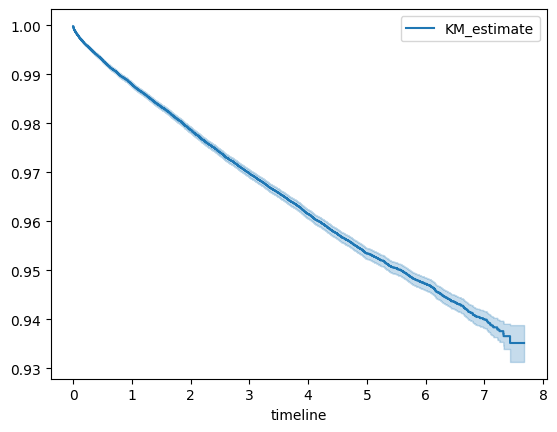

In [6]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(durations=code_15['timey'], event_observed=code_15['death'])
kmf.plot_survival_function()

In [7]:
import os
from datetime import timedelta
data_folder = '/media/Volume/data/MIMIC_IV'

machine_measurement_path = os.path.join(data_folder, 'machine_measurements.csv')
if not os.path.exists(machine_measurement_path):
    raise FileNotFoundError(f"MIMIC-IV: machine measurements file not found at {machine_measurement_path}")
dat_ecg = pd.read_csv(machine_measurement_path)

record_list_path = os.path.join(data_folder, 'record_list.csv')
if not os.path.exists(record_list_path):
    raise FileNotFoundError(f"MIMIC-IV: record list file not found at {record_list_path}")
dat_record = pd.read_csv(record_list_path)

patients_path = os.path.join(data_folder, 'patients.csv.gz')
if not os.path.exists(patients_path):
    raise FileNotFoundError(f"MIMIC-IV: patients file not found at {patients_path}")
dat_patients = pd.read_csv(patients_path)
dat_patients['dod'] = pd.to_datetime(dat_patients['dod'], errors='coerce')

admission_path = os.path.join(data_folder, 'admissions.csv.gz')
if not os.path.exists(admission_path):
    raise FileNotFoundError(f"MIMIC-IV: admissions file not found at {admission_path}")
dat_admissions = pd.read_csv(admission_path)

# the last discharge date
max_disch_time = dat_admissions.sort_values(["subject_id",'dischtime']).groupby("subject_id").last().reset_index()
max_disch_time = max_disch_time[['subject_id', 'dischtime']]
max_disch_time.rename(columns={'dischtime': 'max_disch_time'}, inplace=True)
max_disch_time = max_disch_time.reset_index()

dat_ecg['ecg_time'] = pd.to_datetime(dat_ecg['ecg_time'], errors='coerce')  # Convert to datetime, handle errors
dat_ecg['ecg_date'] = dat_ecg['ecg_time'].dt.date

# the last ecg time
max_ecg_time = dat_record.sort_values(by=['subject_id', 'ecg_time']).groupby('subject_id').last().reset_index()
max_ecg_time.rename(columns={'ecg_time': 'max_ecg_time'}, inplace=True)
max_ecg_time = max_ecg_time[['subject_id', 'max_ecg_time']]
max_ecg_time = max_ecg_time.reset_index()

dat = pd.merge(dat_ecg, dat_record, on=["subject_id", "study_id"])
dat = dat.rename(columns={"ecg_time_y":"ecg_time", "ecg_date_y":"ecg_date"})
dat = pd.merge(dat, dat_patients, how="inner", on="subject_id")
dat = pd.merge(dat, max_ecg_time, how="left", on="subject_id")
dat['ecg_time'] = pd.to_datetime(dat['ecg_time'], errors='coerce')  # Convert to datetime, handle errors
dat = pd.merge(dat, max_disch_time, how="left", on="subject_id")
dat['max_disch_time'] = pd.to_datetime(dat['max_disch_time'], errors='coerce')  # Convert to datetime, handle errors
dat['max_ecg_time'] = pd.to_datetime(dat['max_ecg_time'], errors='coerce')  # Convert to datetime, handle errors
dat["death"] = ~pd.isna(dat["dod"])

dat['dod'] = pd.to_datetime(dat['dod'], errors='coerce')  # Convert to datetime, handle errors
dat["timey"] = dat['dod'].dt.date - dat["ecg_time"].dt.date
dat['timey'] = dat['timey'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))
dat['timey'] = dat['timey'].fillna(dat["max_ecg_time"].dt.date - dat["ecg_time"].dt.date)
dat['timey'] = dat['timey'].dt.days / 365

# fix file name to align with previous implementation
dat['file_name'] = dat['path']

# get only ecgs with timey > 0
tab_data = dat[dat["timey"].notna() & (dat["timey"] > 0)]

/tmp/ipykernel_2708788/4179868368.py:8: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dat_ecg = pd.read_csv(machine_measurement_path)
/tmp/ipykernel_2708788/4179868368.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dat['timey'] = dat['timey'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))


<Axes: xlabel='timeline'>

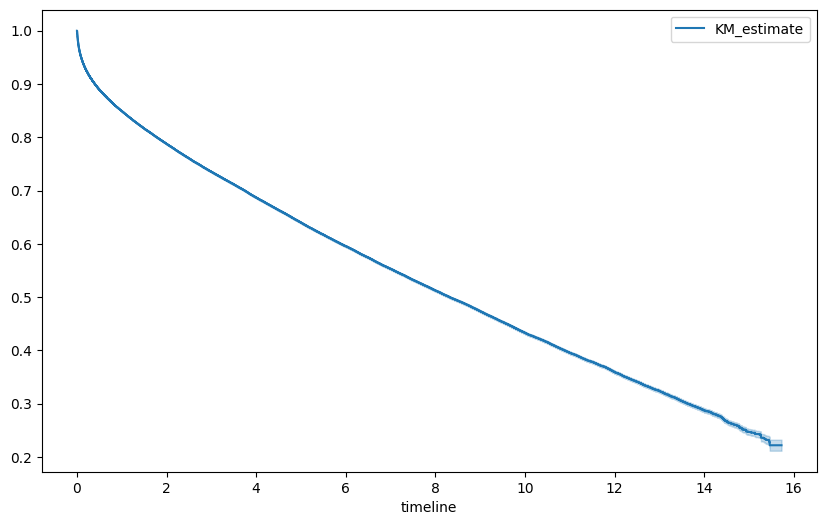

In [8]:
kmf_mimic = KaplanMeierFitter()
kmf_mimic.fit(durations=tab_data['timey'], event_observed=tab_data['death'])
plt.figure(figsize=(10, 6))
kmf_mimic.plot_survival_function()

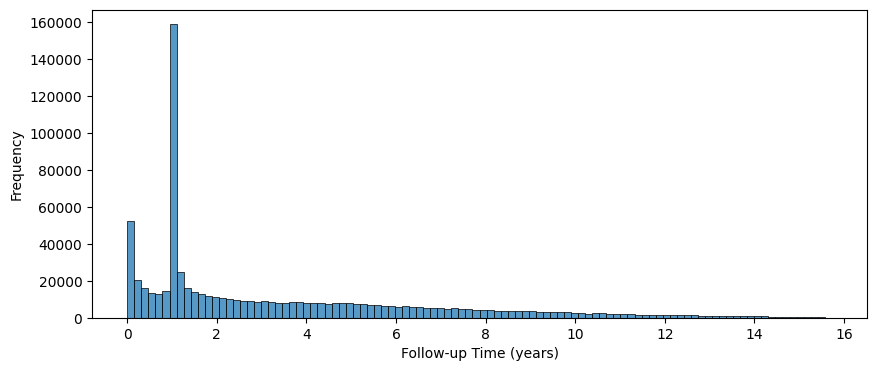

In [9]:
# plot distribution of timey
plt.figure(figsize=(10, 4))
sns.histplot(tab_data['timey'], bins=100, kde=False)
# plt.title('Distribution of Follow-up Time (timey)')
plt.xlabel('Follow-up Time (years)')
plt.ylabel('Frequency')
plt.show()

In [10]:
# loading the xlstm model
import utils.utils as utils
from models.classification import xLSTMClassification

# embedding_size: 1024
# encoder_type: vanilla
# xlstm_config: ["s","s","m","m","s", "s","m","m","s"]
# checkpoint: pretrain-xLSTM/0rgc8fun/checkpoints/epoch=49-step=504700.ckpt
# use_final_layer_norm: false
# cls_normalization: null

config = utils.parse_config('configs/train_mortality_run_config.yaml', 'config_defaults/train_mortality_config_defaults.yaml')
config.embedding_size = 1024
config.encoder_type = 'vanilla'
config.xlstm_config = ["s","s","m","m","s","s","m","m","s"]
config.checkpoint = 'train-mortality/hq0hw9ne/checkpoints/epoch=11-step=4308.ckpt'
config.num_workers = 32

# load mortality default config
model = utils.get_base_model(config)

/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [11]:
import dataset.mimic_iv as mimic
from torch.utils.data import DataLoader
from dataset.generic_utils import get_transforms
import dataset.generic_utils as generic_utils



test_dataset = mimic.ECGMIMICDataset(config, split='all', global_augmentations=get_transforms(config, split='all'), downstream_task='mortality')
test_dataloader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, collate_fn=generic_utils.make_collate_fn_task(config, ['death', 'timey']))



using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


/home/luna97/Research/MIT-BIH_ecg_arrhytmia/dataset/mimic_iv.py:88: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dat_ecg = pd.read_csv(machine_measurement_path)
/home/luna97/Research/MIT-BIH_ecg_arrhytmia/dataset/mimic_iv.py:133: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dat['timey'] = dat['timey'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))


   subject_id  study_id  cart_id          ecg_time_x           report_0  \
0    10000032  40689238  6848296 2180-07-23 08:44:00       Sinus rhythm   
1    10000032  44458630  6848296 2180-07-23 09:54:00       Sinus rhythm   
2    10000032  49036311  6376932 2180-08-06 09:07:00  Sinus tachycardia   
3    10000117  45090959  6214760 2181-03-04 17:14:00       Sinus rhythm   
4    10000117  48446569  6632385 2183-09-18 13:52:00       Sinus rhythm   

                            report_1                    report_2  \
0  Possible right atrial abnormality                         NaN   
1  Possible right atrial abnormality                         NaN   
2                                NaN  Normal ECG except for rate   
3                                NaN                  Normal ECG   
4                                NaN                         NaN   

         report_3 report_4 report_5  ... anchor_age anchor_year  \
0  Borderline ECG      NaN      NaN  ...         52        2180   
1  Bor

In [12]:
from tqdm import tqdm
import torch

def eval_model(model, dataloader):
    model.eval()
    model.to('cuda')
    outputs_list = []
    death_list = []
    timey_list = []
    for batch in tqdm(dataloader):
        inputs = batch['signals'].to('cuda')
        deaths = batch['death']
        timeys = batch['timey']
        with torch.no_grad():
            outputs = model(inputs)
            outputs_list.extend(outputs.flatten().cpu().numpy())
            death_list.extend(deaths.cpu().numpy())
            timey_list.extend(timeys.cpu().numpy())
        # process outputs
    return outputs_list, death_list, timey_list

In [13]:
outputs_list, death_list, timey_list = eval_model(model, test_dataloader)

100%|██████████| 1439/1439 [04:05<00:00,  5.85it/s]


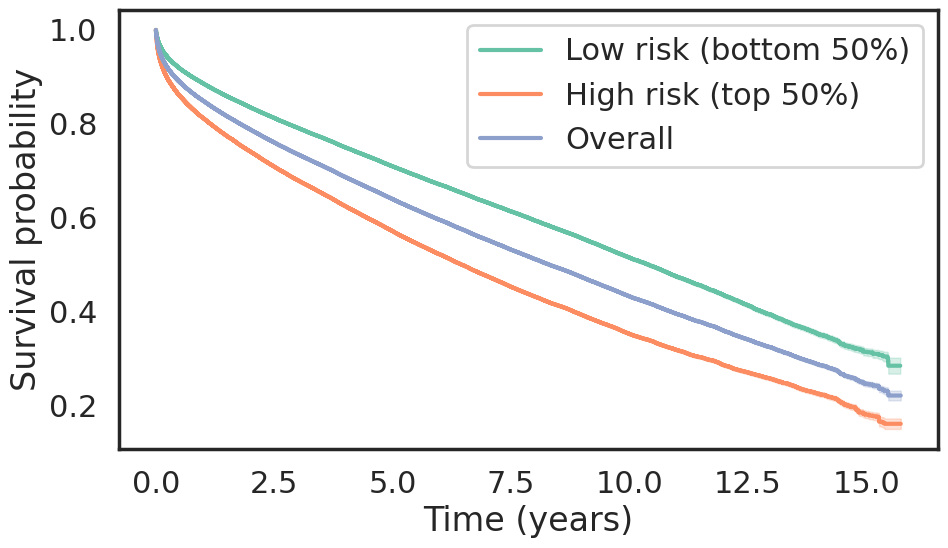

In [23]:
outputs = np.array(outputs_list)
events = np.array(death_list)
times = np.array(timey_list)

median_risk = np.median(outputs)
high_mask = outputs >= median_risk
low_mask = outputs < median_risk

# Initialize KM fitter
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

sns.set_style("white")
sns.set_context("poster")   # nicer font sizes for presentations
palette = sns.color_palette("Set2")  # e.g., pastel but distinct colors

# Low-risk KM curve
kmf.fit(times[low_mask], events[low_mask], label="Low risk (bottom 50%)")
ax = kmf.plot(ci_show=True, color=palette[0])

# High-risk KM curve
kmf.fit(times[high_mask], events[high_mask], label="High risk (top 50%)")
kmf.plot(ax=ax, ci_show=True, color=palette[1])

kmf.fit(times, events, label="Overall")
kmf.plot(ax=ax, ci_show=True, color=palette[2])

# plt.title("Kaplan–Meier Curves by Predicted Risk Group")
plt.xlabel("Time (years)")
plt.ylabel("Survival probability")
plt.legend()

plt.tight_layout()
plt.savefig('figs/km_curve_mortality.svg')